In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Chicken Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 807 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


In [ ]:
VGG16

In [3]:
class_weights = None

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze MOST layers but not too many
for layer in base_model.layers[:-6]:
    layer.trainable = False

for layer in base_model.layers[-6:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),   
    loss='categorical_crossentropy',        
    metrics=['accuracy']
)


In [4]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [5]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.5452 - loss: 1.1071 - val_accuracy: 0.5850 - val_loss: 1.4828 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.7522 - loss: 0.6491 - val_accuracy: 0.5250 - val_loss: 2.0869 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.8067 - loss: 0.5277 - val_accuracy: 0.7250 - val_loss: 1.0128 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8538 - loss: 0.4209 - val_accuracy: 0.7250 - val_loss: 1.0365 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.8711 - loss: 0.3623 - val_accuracy: 0.8250 - val_loss: 0.6659 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8971 - loss: 0.3007 - val_accuracy: 0.8050 - val_loss: 0.8428 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.9257 

In [6]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8450 - loss: 0.6658
Validation Accuracy: 0.8450000286102295


13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step


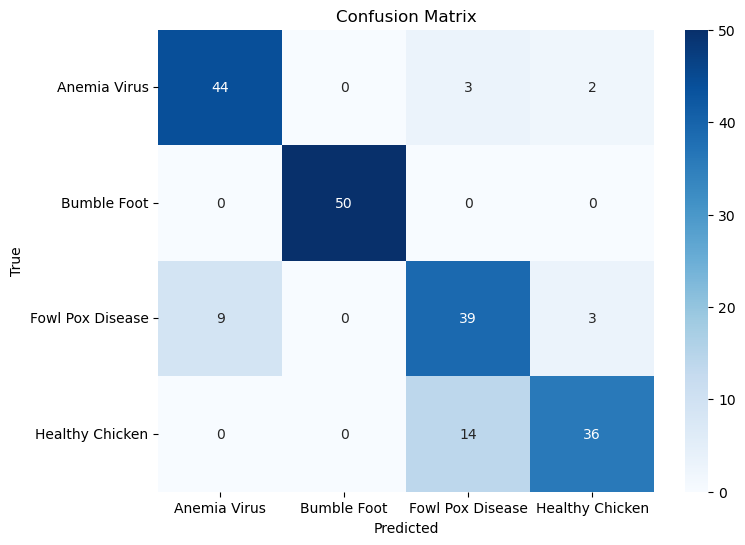

                  precision    recall  f1-score   support

    Anemia Virus       0.83      0.90      0.86        49
     Bumble Foot       1.00      1.00      1.00        50
Fowl Pox Disease       0.70      0.76      0.73        51
 Healthy Chicken       0.88      0.72      0.79        50

        accuracy                           0.84       200
       macro avg       0.85      0.85      0.85       200
    weighted avg       0.85      0.84      0.85       200



In [7]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [8]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T

print(metrics_df)

                  TP  FP  FN   TN
Anemia Virus      44   9   5  142
Bumble Foot       50   0   0  150
Fowl Pox Disease  39  17  12  132
Healthy Chicken   36   5  14  145


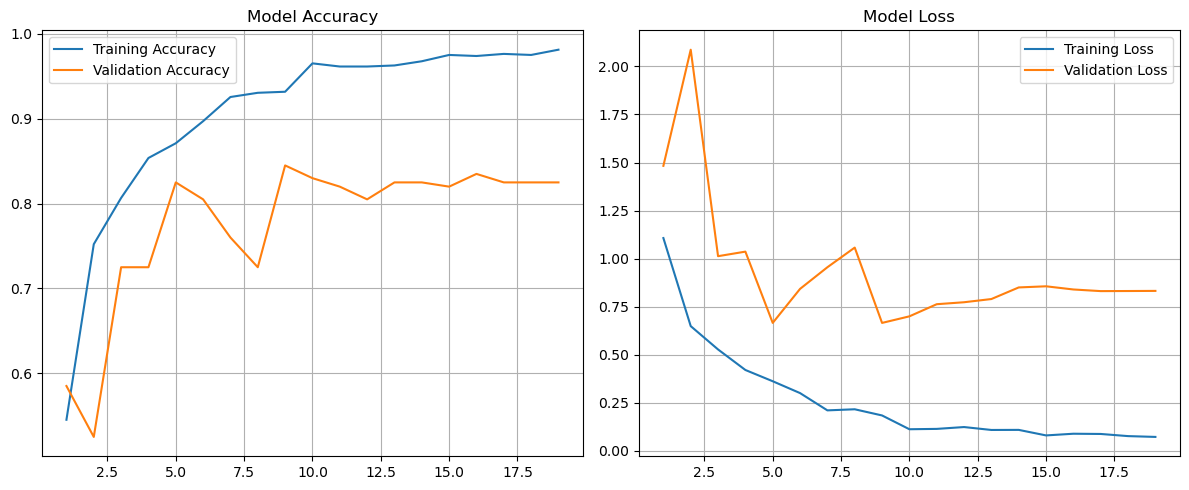

In [9]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
model.save('AImodel_VGG162_Chicken.keras')

In [11]:
model.save('AImodel_VGG162_Chicken.h5')

In [ ]:
ResNet50

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [13]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Chicken Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 808 images belonging to 4 classes.
Found 201 images belonging to 4 classes.


In [14]:
class_weights = None

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

for layer in base_model.layers[-15:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [16]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 740ms/step - accuracy: 0.5421 - loss: 1.2637 - val_accuracy: 0.7214 - val_loss: 0.7652 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 719ms/step - accuracy: 0.7550 - loss: 0.5867 - val_accuracy: 0.7761 - val_loss: 0.8134 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 724ms/step - accuracy: 0.8490 - loss: 0.4004 - val_accuracy: 0.8060 - val_loss: 0.7514 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 709ms/step - accuracy: 0.8973 - loss: 0.3203 - val_accuracy: 0.8209 - val_loss: 0.7513 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 717ms/step - accuracy: 0.9059 - loss: 0.2626 - val_accuracy: 0.8209 - val_loss: 0.7796 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 721ms/step - accuracy: 0.9344 - loss: 0.1905 - val_accuracy: 0.8159 - val_loss: 0.6529 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 724ms/step - acc

In [17]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 478ms/step - accuracy: 0.8159 - loss: 0.6529
Validation Accuracy: 0.8159204125404358


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 549ms/step


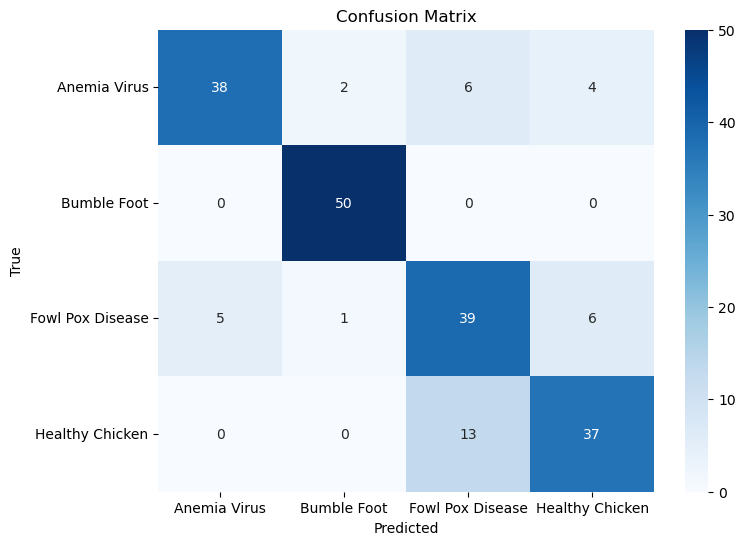

                  precision    recall  f1-score   support

    Anemia Virus       0.88      0.76      0.82        50
     Bumble Foot       0.94      1.00      0.97        50
Fowl Pox Disease       0.67      0.76      0.72        51
 Healthy Chicken       0.79      0.74      0.76        50

        accuracy                           0.82       201
       macro avg       0.82      0.82      0.82       201
    weighted avg       0.82      0.82      0.82       201



In [18]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [19]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                  TP  FP  FN   TN
Anemia Virus      38   5  12  146
Bumble Foot       50   3   0  148
Fowl Pox Disease  39  19  12  131
Healthy Chicken   37  10  13  141


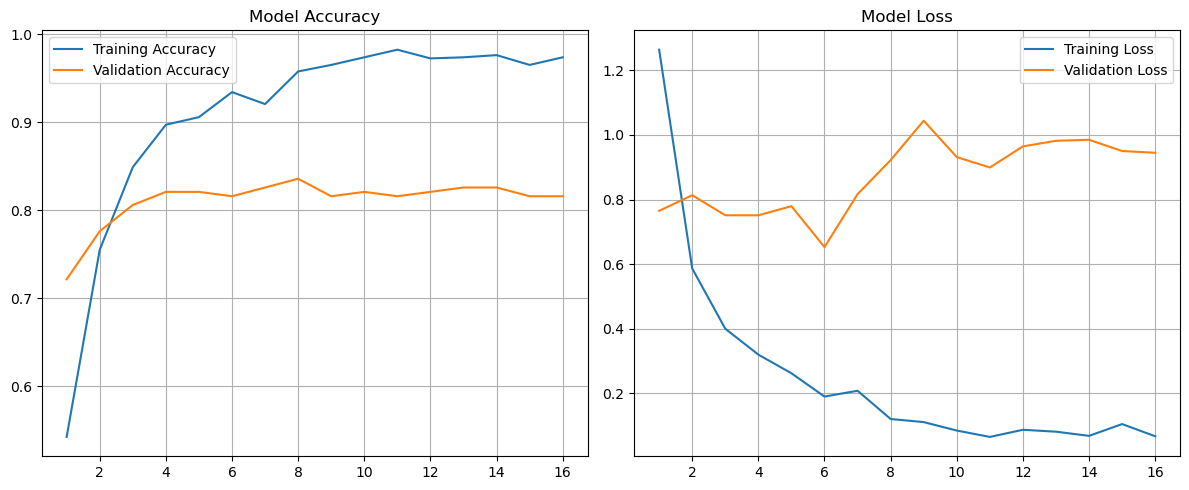

In [20]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
model.save('AImodel_ResNet502_Chicken.keras')

In [ ]:
DenseNet121

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [23]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Chicken Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 808 images belonging to 4 classes.
Found 201 images belonging to 4 classes.


In [24]:
class_weights = None

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers but allow deeper learning
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [26]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 47s 730ms/step - accuracy: 0.3948 - loss: 1.3783 - val_accuracy: 0.7264 - val_loss: 0.9421 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 668ms/step - accuracy: 0.6361 - loss: 0.9215 - val_accuracy: 0.7761 - val_loss: 0.6994 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 703ms/step - accuracy: 0.7153 - loss: 0.7217 - val_accuracy: 0.8209 - val_loss: 0.5734 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 655ms/step - accuracy: 0.7735 - loss: 0.5969 - val_accuracy: 0.8308 - val_loss: 0.5162 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 663ms/step - accuracy: 0.7983 - loss: 0.5342 - val_accuracy: 0.8308 - val_loss: 0.4826 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 668ms/step - accuracy: 0.8403 - loss: 0.4305 - val_accuracy: 0.8507 - val_loss: 0.4633 - learning_rate: 1.0000e-04
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 664ms/step - acc

In [27]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 470ms/step - accuracy: 0.8408 - loss: 0.4573
Validation Accuracy: 0.8407959938049316


13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 618ms/step


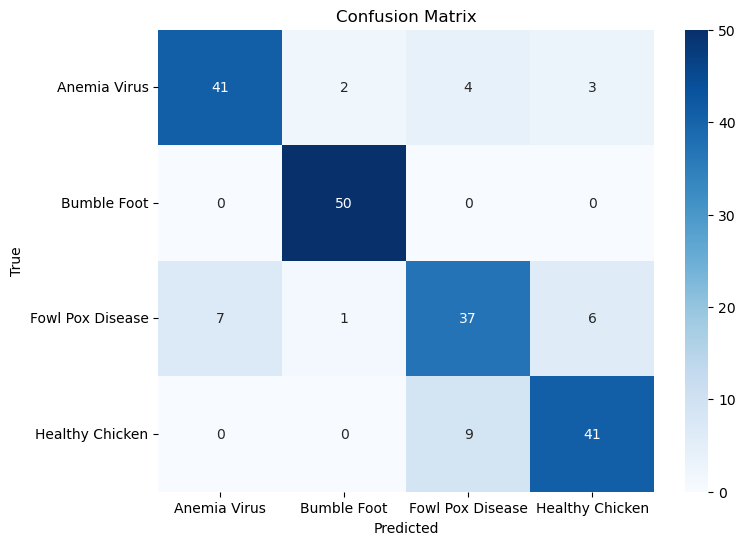

                  precision    recall  f1-score   support

    Anemia Virus       0.85      0.82      0.84        50
     Bumble Foot       0.94      1.00      0.97        50
Fowl Pox Disease       0.74      0.73      0.73        51
 Healthy Chicken       0.82      0.82      0.82        50

        accuracy                           0.84       201
       macro avg       0.84      0.84      0.84       201
    weighted avg       0.84      0.84      0.84       201



In [28]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [29]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                  TP  FP  FN   TN
Anemia Virus      41   7   9  144
Bumble Foot       50   3   0  148
Fowl Pox Disease  37  13  14  137
Healthy Chicken   41   9   9  142


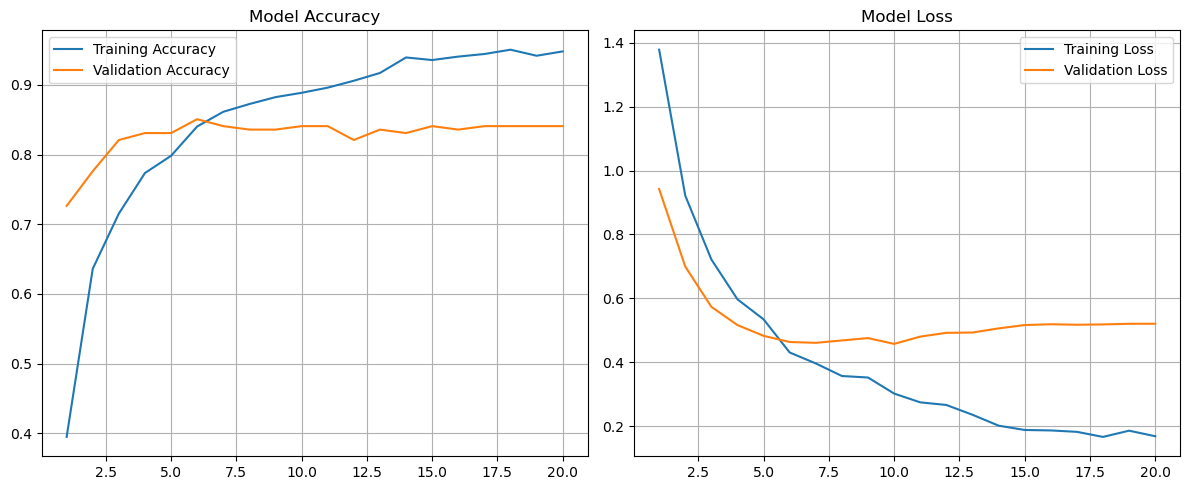

In [30]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
model.save('AImodel_DenseNet1212_Chicken.keras')

In [ ]:
MobileNet V2

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [33]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Chicken Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 808 images belonging to 4 classes.
Found 201 images belonging to 4 classes.


In [34]:
class_weights = None

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers; fine-tune last 50 layers for small dataset
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [36]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 256ms/step - accuracy: 0.5173 - loss: 1.2114 - val_accuracy: 0.6517 - val_loss: 0.8038 - learning_rate: 1.0000e-04
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.7277 - loss: 0.6733 - val_accuracy: 0.6915 - val_loss: 0.6621 - learning_rate: 1.0000e-04
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 241ms/step - accuracy: 0.8441 - loss: 0.4506 - val_accuracy: 0.6667 - val_loss: 0.9461 - learning_rate: 1.0000e-04
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - accuracy: 0.8601 - loss: 0.3792 - val_accuracy: 0.6766 - val_loss: 0.9756 - learning_rate: 1.0000e-04
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - accuracy: 0.9022 - loss: 0.2804 - val_accuracy: 0.6816 - val_loss: 1.2304 - learning_rate: 1.0000e-04
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 252ms/step - accuracy: 0.9010 - loss: 0.2667 - val_accuracy: 0.7015 - val_loss: 1.0262 - learning_rate: 3.0000e-05
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - acc

In [37]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.6915 - loss: 0.6621
Validation Accuracy: 0.6915422677993774


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step


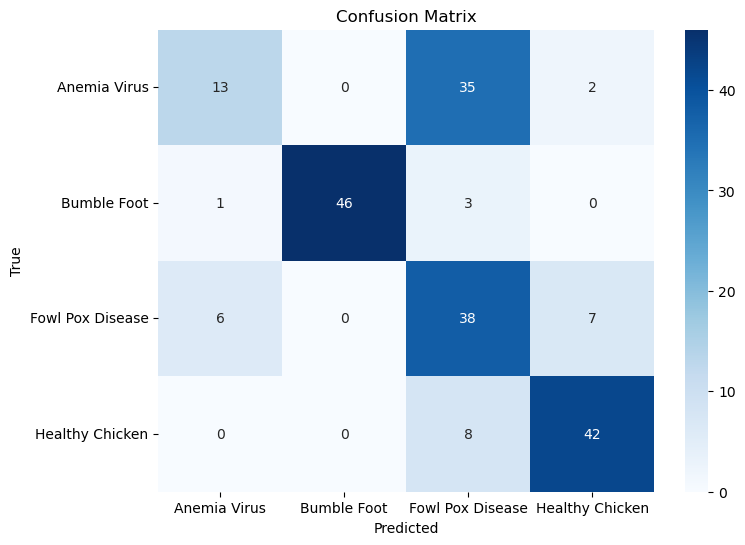

                  precision    recall  f1-score   support

    Anemia Virus       0.65      0.26      0.37        50
     Bumble Foot       1.00      0.92      0.96        50
Fowl Pox Disease       0.45      0.75      0.56        51
 Healthy Chicken       0.82      0.84      0.83        50

        accuracy                           0.69       201
       macro avg       0.73      0.69      0.68       201
    weighted avg       0.73      0.69      0.68       201



In [38]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [39]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                  TP  FP  FN   TN
Anemia Virus      13   7  37  144
Bumble Foot       46   0   4  151
Fowl Pox Disease  38  46  13  104
Healthy Chicken   42   9   8  142


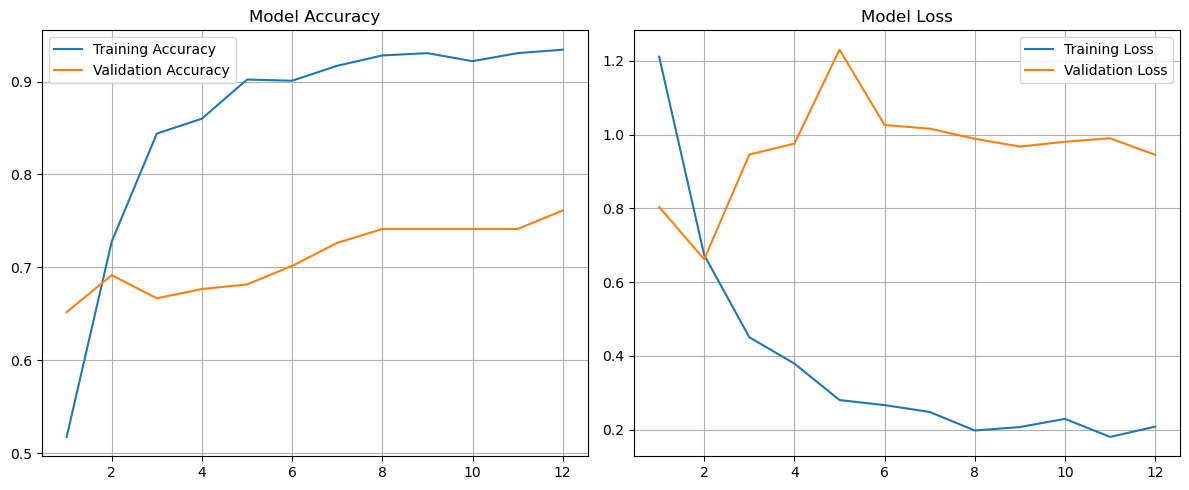

In [40]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
model.save('AImodel_MobileNetV22_Chicken.keras')                                                                

In [ ]:
Vision Transformer (ViT)

In [1]:
!pip install vit-keras
!pip install tensorflow-addons

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from vit_keras import vit
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [3]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Chicken Dataset'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 807 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


In [4]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.00875), 1: np.float64(1.0037313432835822), 2: np.float64(0.9841463414634146), 3: np.float64(1.0037313432835822)}


In [5]:
vit_model = vit.vit_b16(
    image_size=224,
    pretrained=True,
    include_top=False,
    pretrained_top=False
)

# Freeze most layers, fine-tune last 15
for layer in vit_model.layers[:-15]:
    layer.trainable = False

for layer in vit_model.layers[-15:]:
    layer.trainable = True

x = vit_model.output
x = Flatten()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=vit_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.00003),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/vit_keras/utils.py:85: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [7]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 478s 9s/step - accuracy: 0.3829 - loss: 1.6396 - val_accuracy: 0.7300 - val_loss: 0.8601 - learning_rate: 3.0000e-05
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 454s 9s/step - accuracy: 0.6121 - loss: 1.1804 - val_accuracy: 0.7650 - val_loss: 0.8030 - learning_rate: 3.0000e-05
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 448s 9s/step - accuracy: 0.7138 - loss: 0.9905 - val_accuracy: 0.8050 - val_loss: 0.7338 - learning_rate: 3.0000e-05
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 448s 9s/step - accuracy: 0.7633 - loss: 0.8711 - val_accuracy: 0.7950 - val_loss: 0.7350 - learning_rate: 3.0000e-05
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 443s 9s/step - accuracy: 0.8265 - loss: 0.7590 - val_accuracy: 0.8250 - val_loss: 0.7408 - learning_rate: 3.0000e-05
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 445s 9s/step - accuracy: 0.8525 - loss: 0.7145 - val_accuracy: 0.8450 - val_loss: 0.7226 - learning_rate: 3.0000e-05
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 447s 9s/step - accuracy: 0.8786 

In [8]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.9000 - loss: 0.6987
Validation Accuracy: 0.8999999761581421


13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step


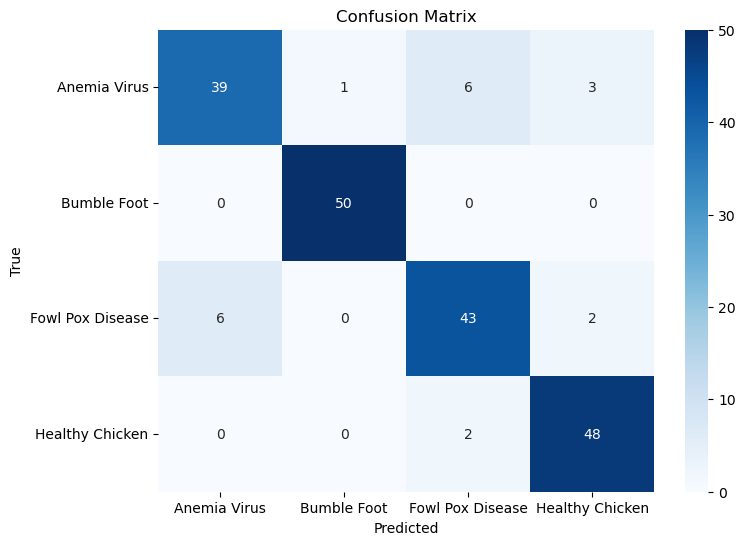

                  precision    recall  f1-score   support

    Anemia Virus       0.87      0.80      0.83        49
     Bumble Foot       0.98      1.00      0.99        50
Fowl Pox Disease       0.84      0.84      0.84        51
 Healthy Chicken       0.91      0.96      0.93        50

        accuracy                           0.90       200
       macro avg       0.90      0.90      0.90       200
    weighted avg       0.90      0.90      0.90       200



In [9]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [10]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                  TP  FP  FN   TN
Anemia Virus      39   6  10  145
Bumble Foot       50   1   0  149
Fowl Pox Disease  43   8   8  141
Healthy Chicken   48   5   2  145


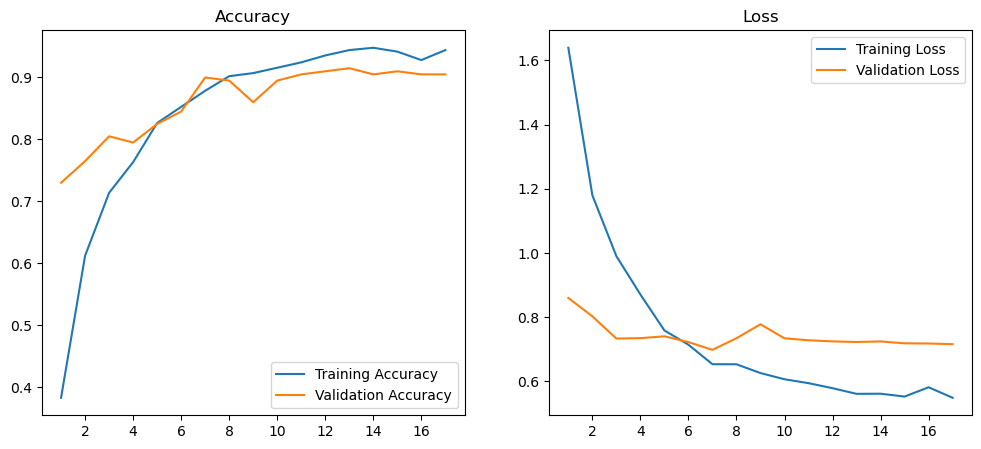

In [11]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [14]:
model.save('AImodel_ViT_Chicken.keras')

In [15]:
model.save('AImodel_ViT_Chicken.h5')